<a href="https://colab.research.google.com/github/hadasecohen/streaming-vae-anomaly-detection/blob/main/notebooks/demo_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Streaming VAE Anomaly Detection — GPU Demo

Clones the repo and runs `demo.py` end to end on Colab GPU: offline
warmup training + online streaming anomaly detection on ERA5 dataset.

Runtime menu → Change runtime type → GPU, then run all cells.

### Choose which experiment to run

In [ ]:
ANOM = "contextual"    # point | group | contextual
ARCH = "mlp_cyclic"    # mlp | mlp_cyclic | lstm | transformer
GPU = 0                 # GPU index, e.g. 0 -> cuda:0; ignored when ANOM == "point" (always CPU)

print(f"ANOM={ANOM!r}  ARCH={ARCH!r}  GPU={GPU}")

ANOM='contextual'  ARCH='mlp_cyclic'  GPU=0


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))


CUDA available: True
Device: Tesla T4


In [ ]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(
            ["git", "clone", REPO_URL, str(REPO_DIR)],
            check=True,
        )

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/ inside a local checkout,
    # move to the repository root.
    if not Path("scripts/run_all_trials.py").exists():
        os.chdir("..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")

Working directory: /content/repo
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.


### Run `demo.py`

Same script you'd run from a terminal — `python demo.py --anom ... --arch ...`.
See `demo.py --help` for the full option list.

Its output ends with the equivalent `python -m scripts.trial.run_trial <config>` command for this exact experiment, run directly against its tracked config under `modules/standalone_model_env/` instead of through `demo.py` (the architecture is read from the config's own `model.type`, so it doesn't need to be passed separately). To try that command here, paste it into a new cell with a `!` prefix (e.g. `!python -m scripts.trial.run_trial ...`) — this notebook's working directory is already the cloned repo root, so the printed relative path works as-is.

**If this fails with `ModuleNotFoundError: No module named 'src.utils'`**, the compiled `src/` no longer matches Colab's current Python version. You can check which version it targets from the `.so` filenames themselves (e.g. `!ls src/*.so`), then install and use that Python version explicitly in this session as a workaround. Please also [open a GitHub issue](https://github.com/hadasecohen/streaming-vae-anomaly-detection/issues/new) with the full traceback — the repo's compiled `src/` needs to be recompiled and re-released.

In [ ]:
!python demo.py --anom {ANOM} --arch {ARCH} --gpu {GPU}

Experiment : baseline/Contextual_MLP_Cyclic
Config     : /tmp/demo_Contextual_MLP_Cyclic_5yqvi1dn.yaml
Model arch : MLP  (cyclic_recon=True)
Device     : cuda:0
Run dir    : runs/standalone_model_env/baseline/Contextual_MLP_Cyclic

This demo runs one fixed model/anomaly pair for a quick environment check.
To compare architectures or tune hyperparameters directly, run the same
experiment via its tracked config instead of demo.py:

    pip install -r requirements.txt
    python -m scripts.trial.run_trial modules/standalone_model_env/baseline/era5_contextual_MLP_Cyclic_config_standalone.yaml

GLOBAL SEED = 49
Logger: Verbosity=3, logging into: 'runs/standalone_model_env/baseline/Contextual_MLP_Cyclic/run.log'
Small σ features (<0.05): 1/17
Minimum σ: 0.0010000000474974513
Max |Z|: 9.122962
Mean |Z|: 0.7863893
  column                          warmup_min  warmup_max    test_min    test_max
  u100                                -3.983       5.162      -4.027       4.223
  v100              

### Inspect the run

### Quantitative Results

Two tables summarize the run: a performance table (runtime, throughput, GPU memory, model size) and a metrics table with the run's F1, precision, recall, ROC-AUC, and PR-AUC — one column per anomaly-scoring signal (reconstruction error, KL divergence, per-metric latent statistics, and the combined final score). Use the metrics table to answer *how well* the model separated anomalies from normal data, and how scoring signals other than `recon` (e.g. `elbo`, `elbo with variance penalty`, etc.) performed — useful for identifying which scoring signal is preferable by architectures or for different anomaly types.

In [ ]:
import re
import json as _json
import yaml
import pandas as pd

_arch_dir = {
    "mlp": "MLP", "mlp_cyc": "MLP_Cyclic", "mlp_cyclic": "MLP_Cyclic",
    "lstm": "LSTM", "tr": "Transformer", "tf": "Transformer",
    "transformer": "Transformer", "transtormer": "Transformer",
}[ARCH]
_config_path = f"modules/standalone_model_env/baseline/era5_{ANOM}_{_arch_dir}_config_standalone.yaml"
with open(_config_path) as f:
    _cfg = yaml.safe_load(f)

RUN_DIR = _cfg["common"]["logging"]["run_dir"]
TEST_PATH = _cfg["data"]["test_path"]

# PERFORMANCE (single run-level variables): already written as structured
# JSON alongside run.log, no parsing needed.
with open(f"{RUN_DIR}/_perf_summary.json") as f:
    perf = _json.load(f)
perf_df = pd.DataFrame(perf.items(), columns=["variable", "value"]).set_index("variable")
perf_df["value"] = perf_df["value"].apply(lambda v: f"{v:,.0f}" if float(v).is_integer() else f"{v:,.3f}")
display(perf_df)

# METRICS (one column per anomaly-scoring signal): only available as the
# pipe-delimited table run.log prints, so parse that block out.
with open(f"{RUN_DIR}/run.log") as f:
    log_text = f.read()
_table_block = re.search(r"METRICS.*?\n\n(.*?)\n\n", log_text, re.DOTALL).group(1)
_table_lines = _table_block.strip("\n").split("\n")
_header = [c.strip() for c in _table_lines[0].split("|")]
_rows = [[c.strip() for c in line.split("|")] for line in _table_lines[2:]]
metrics_df = pd.DataFrame(_rows, columns=_header).set_index(_header[0]).apply(pd.to_numeric, errors="coerce")
display(metrics_df.style.format("{:.3f}"))

,value
variable,
total_s,949.380
warmup_s,374.580
stream_s,574.800
n_warmup_samples,"10,068"
n_stream_steps,"18,883"
warmup_samples_per_sec,26.900
stream_steps_per_sec,32.900
n_params,"707,418"
gpu_peak_mb,724.500


,final,elbo,recon,kl,mah_diag,mu_norm,logvar_sumexp,logvar_target_mse,elbo_w_var,gmm_latent
metric,,,,,,,,,,
conf_pr,0.755,0.700,0.755,0.060,0.089,0.039,0.084,0.114,0.220,0.412
conf_roc,0.953,0.928,0.953,0.570,0.604,0.393,0.474,0.532,0.613,0.798
f1,0.718,0.638,0.718,0.009,0.002,0.004,0.031,0.009,0.145,0.414
precision,0.772,0.814,0.772,0.211,0.125,0.065,0.824,0.400,0.795,0.648
recall,0.672,0.525,0.672,0.005,0.001,0.002,0.016,0.005,0.080,0.304
accuracy,0.976,0.972,0.976,0.953,0.953,0.952,0.954,0.953,0.956,0.960
score_mean,0.253,0.264,0.253,0.250,0.259,0.249,0.263,0.266,0.261,0.241
score_std,0.209,0.193,0.209,0.144,0.142,0.145,0.152,0.155,0.163,0.182


### Qualitative Results (Plots)

The plots below give a visual, example-level view of the same run. Use them to sanity-check the numbers above

### Score histogram (normal vs. anomaly)

How cleanly the model's confidence scores separate normal from anomalous points — the more the green (normal) and red (anomaly) distributions pull apart, the more reliable the score.

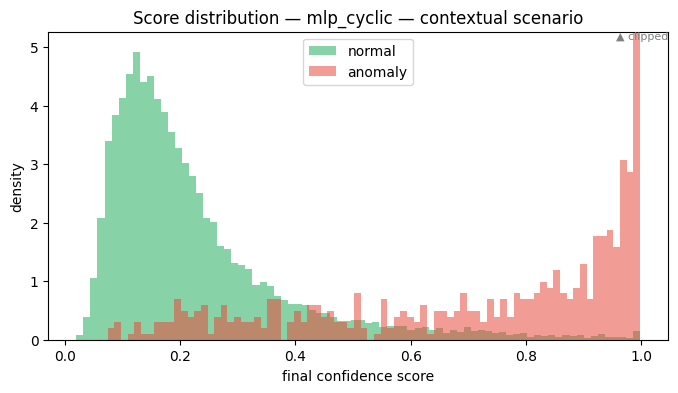

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

preds = pd.read_csv(
    f"{RUN_DIR}/trial_predictions.csv", skiprows=1, header=None,
    names=["ts_start", "ts_end", "step", "confusion", "label",
           "final_pred", "trained", "final_conf", "metrics"],
)

fig, ax = plt.subplots(figsize=(8, 4))
for lbl, color, name in [(0, "#27ae60", "normal"), (1, "#e74c3c", "anomaly")]:
    sub = preds.loc[preds["label"] == lbl, "final_conf"].dropna()
    if len(sub):
        ax.hist(sub, bins=80, alpha=0.55, color=color, density=True, label=name)
ax.set_xlabel("final confidence score")
ax.set_ylabel("density")
ax.set_title(f"Score distribution — {ARCH} — {ANOM} scenario")
ax.legend()

# Clip y-axis when a saturation spike (e.g. many scores pinned near 0 or 1)
# dominates the scale: if the tallest bar is > 3x the 90th-percentile bar,
# cap at 2x p90 so the bulk of the distribution stays visible (matches
# scripts/cross_compare.py's score-histogram clipping).
heights = sorted(p.get_height() for p in ax.patches if p.get_height() > 0)
if len(heights) >= 4:
    p90 = float(np.percentile(heights, 90))
    if heights[-1] > 3.0 * p90 > 0:
        ax.set_ylim(0, p90 * 2.0)
        ax.annotate("▲ clipped", xy=(1, 1), xycoords="axes fraction",
                    fontsize=8, color="gray", ha="right", va="top")

plt.show()

### False-positive rate over time

How cleanly the false-positive rate stays low and flat across the stream — a rising or spiky rolling FPR points to miscalibration developing over time (e.g. an early-warmup burst or later drift); the bucket chart on the right shows whether false positives concentrate in specific parts of the stream rather than spreading evenly.

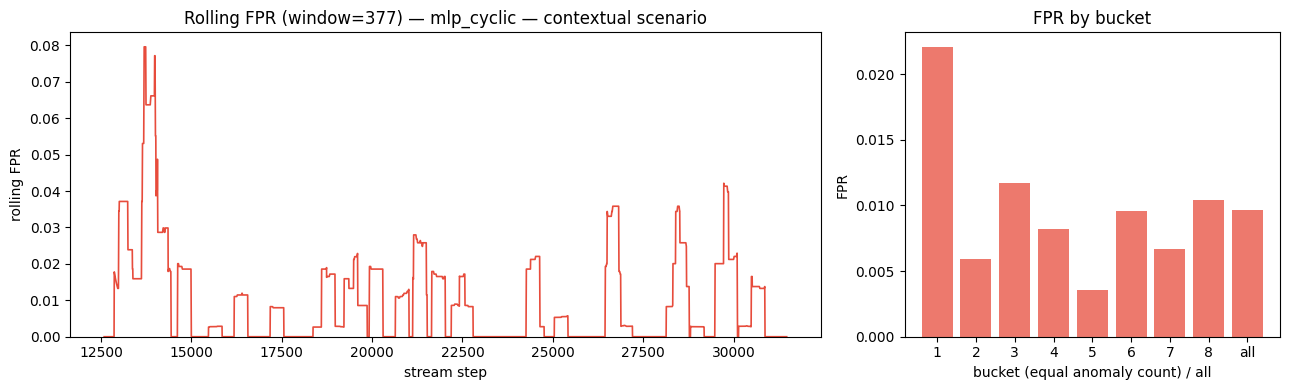

In [ ]:
preds["is_pos"] = preds["confusion"].isin(["TP", "FN"])
preds["is_neg"] = preds["confusion"].isin(["TN", "FP"])
preds["is_fp"]  = preds["confusion"] == "FP"
preds["is_tn"]  = preds["confusion"] == "TN"

# Rolling FPR = FP / (FP + TN) over a sliding window of steps (same formula
# as scripts/plot_fpr_over_time.py's rolling_metric, single-run/no seed averaging).
WINDOW = max(200, len(preds) // 50)
roll_fp = preds["is_fp"].rolling(window=WINDOW, min_periods=1).sum()
roll_tn = preds["is_tn"].rolling(window=WINDOW, min_periods=1).sum()
roll_fpr = (roll_fp / (roll_fp + roll_tn)).where((roll_fp + roll_tn) > 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
ax.plot(preds["step"], roll_fpr, lw=1.2, color="#e74c3c")
ax.set_xlabel("stream step")
ax.set_ylabel("rolling FPR")
ax.set_title(f"Rolling FPR (window={WINDOW}) — {ARCH} — {ANOM} scenario")
ax.set_ylim(bottom=0)

# Bucket display: split into 5 equal-anomaly-count buckets (matches
# scripts/plot_fpr_over_time.py's get_anomaly_cuts/bucket_metric) plus an
# overall column, and show FPR per bucket as a bar chart.
N_BUCKETS = 8
pos_idx = preds.index[preds["is_pos"]].to_numpy()
ax = axes[1]
if len(pos_idx) >= N_BUCKETS:
    cuts = [0] + [int(pos_idx[int(i * len(pos_idx) / N_BUCKETS)]) for i in range(1, N_BUCKETS)] + [len(preds)]
    bucket_labels = [f"{i+1}" for i in range(N_BUCKETS)] + ["all"]
    bucket_fpr = []
    for i in range(N_BUCKETS):
        seg = preds.iloc[cuts[i]:cuts[i + 1]]
        fp, tn = seg["is_fp"].sum(), seg["is_tn"].sum()
        bucket_fpr.append(fp / (fp + tn) if (fp + tn) > 0 else float("nan"))
    fp, tn = preds["is_fp"].sum(), preds["is_tn"].sum()
    bucket_fpr.append(fp / (fp + tn) if (fp + tn) > 0 else float("nan"))
    ax.bar(bucket_labels, bucket_fpr, color="#e74c3c", alpha=0.75)
    ax.set_xlabel("bucket (equal anomaly count) / all")
    ax.set_ylabel("FPR")
    ax.set_title("FPR by bucket")
else:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Confusion counts per metric

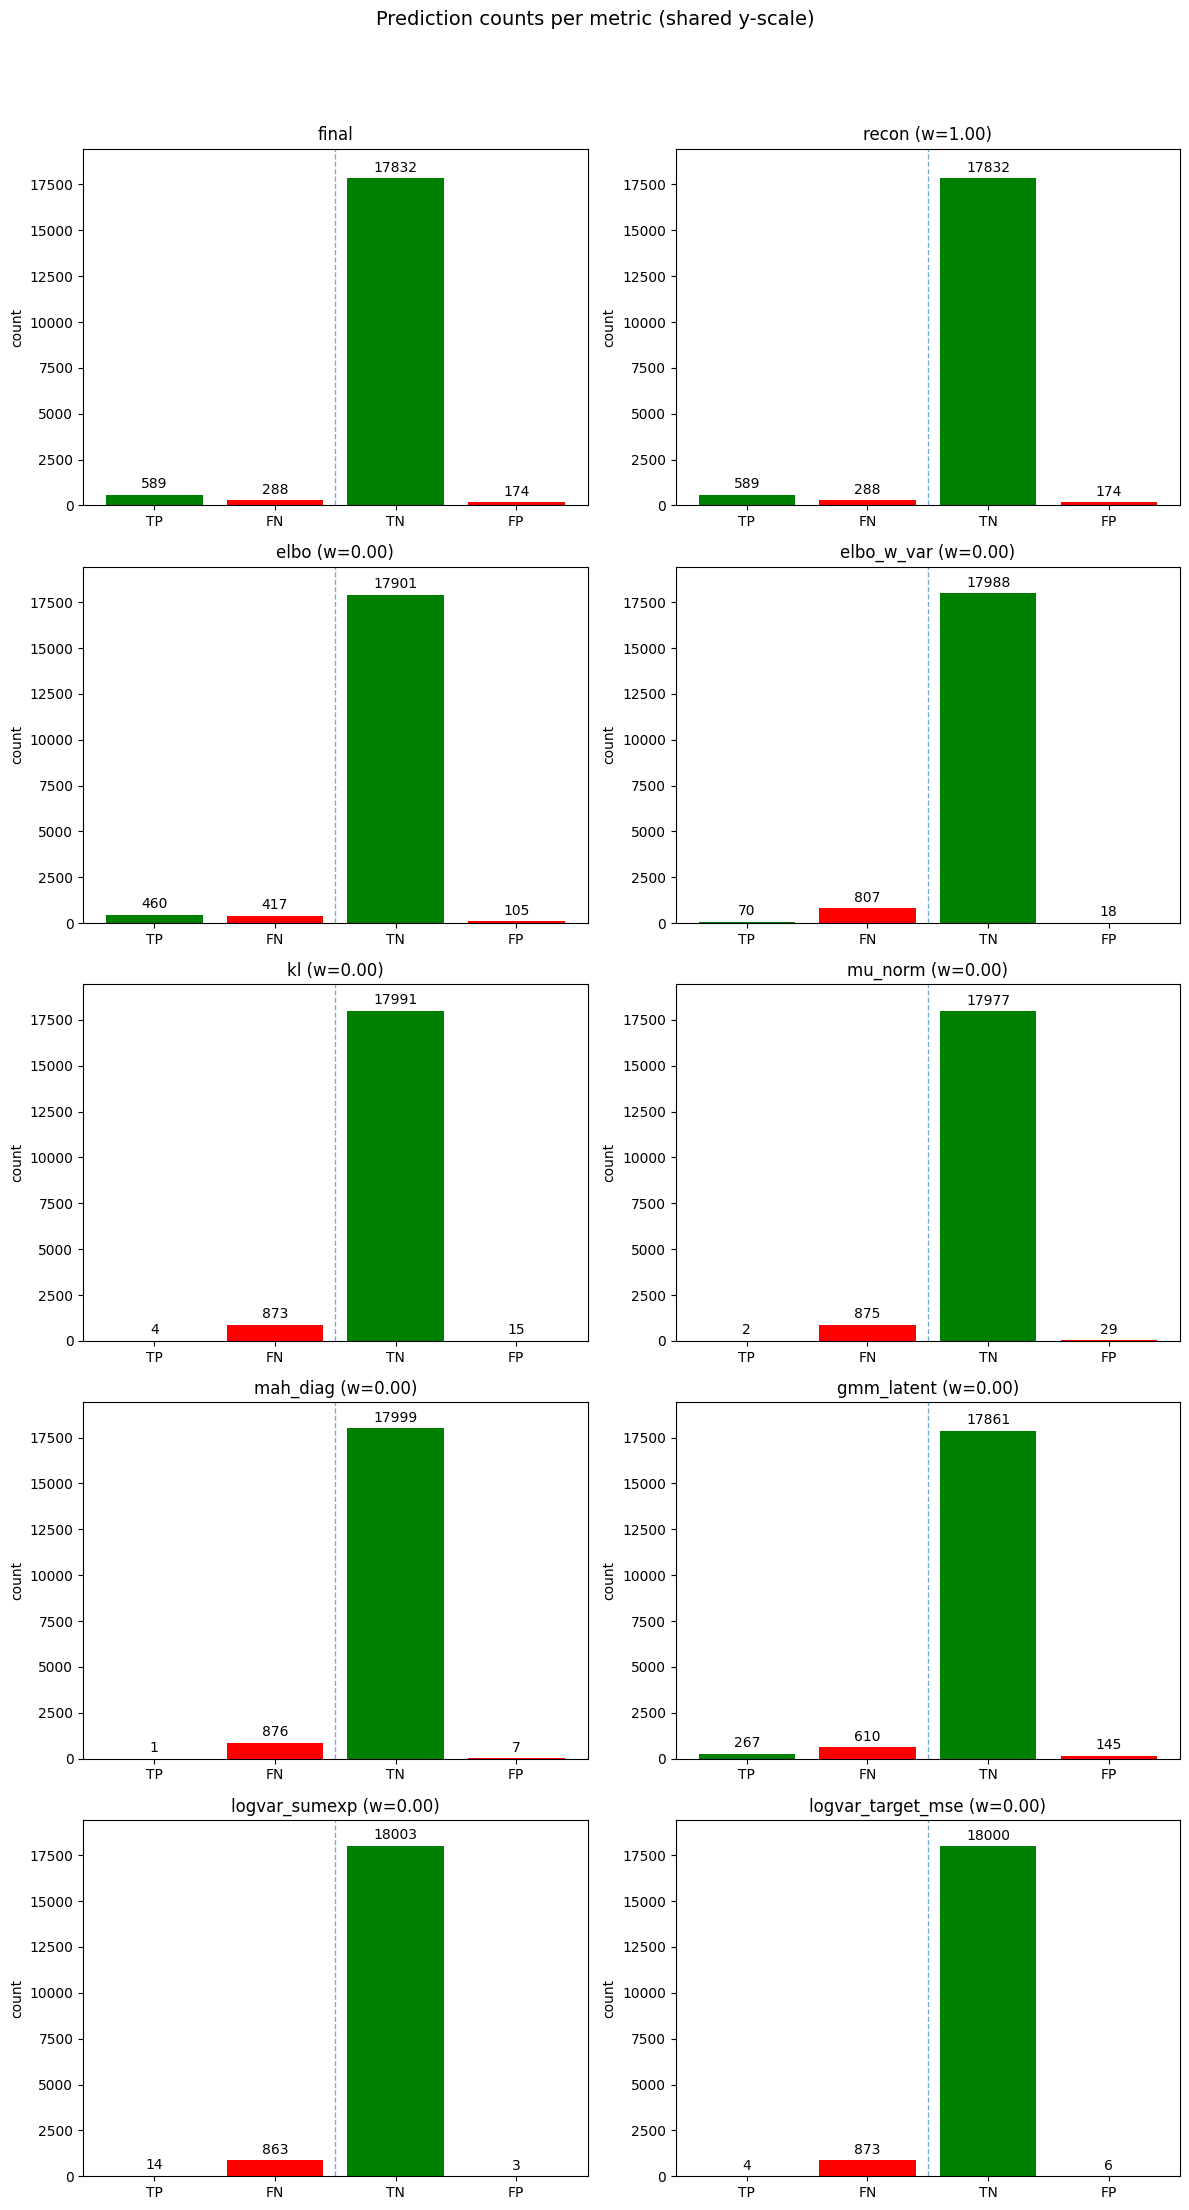

In [ ]:
from IPython.display import Image, display

display(Image(filename=f"{RUN_DIR}/confusion_histograms.png"))

TP/TN counts (green) vs. FN/FP counts (red) for each metric that
contributes to the final score — shows which metrics best separate
normal from anomalous observations, and where errors are concentrated.

### Latent space (UMAP)

A 3D UMAP projection of the run's latent space (`latent_mu.npy`), colored by month and day of year, with TP/FP/FN points overlaid on the month view. Useful for seeing whether the model's latent representation actually organizes by the seasonal structure the data has, and whether anomalies land in a distinct region of that space rather than blending in with normal points. (Hour-of-day coloring is skipped below — this demo's config uses stride=24, so every sample lands at the same hour and that plot carries no information.)

In [30]:
!pip install -q "kaleido==0.2.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.0 MB/s eta 0:00:00


In [31]:
!python scripts/plot_latent_umap.py {RUN_DIR} --from-date 2016-01-01

2026-08-25 16:34:01.488286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loaded latent_mu: (18883, 24)
Date filter: 3716 / 18883 samples kept (2016-01-01 → 2026-03-04)
Fitting UMAP (n_neighbors=150, min_dist=0.1, n=3716, d=24) …
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP done.
Corr with linear time:  U1=+0.016  U2=+0.068  U3=-0.009
Subsampled to 3716 display points
Saved → runs/standalone_model_env/baseline/Contextual_MLP_Cyclic/latent_umap_month.html
Saved → runs/standalone_model_env/baseline/Contextual_MLP_Cyclic/latent_umap_month.png
Saved → runs/standalone_model_env/baseline/Contextual_MLP_Cyclic/latent_umap_hod.h

Each plot is saved as both a static .png snapshot (shown below — renders everywhere) and an interactive .html (rotate/zoom/hover, shown after — only in Colab, since GitHub's and VS Code's notebook previews block the external script it depends on).

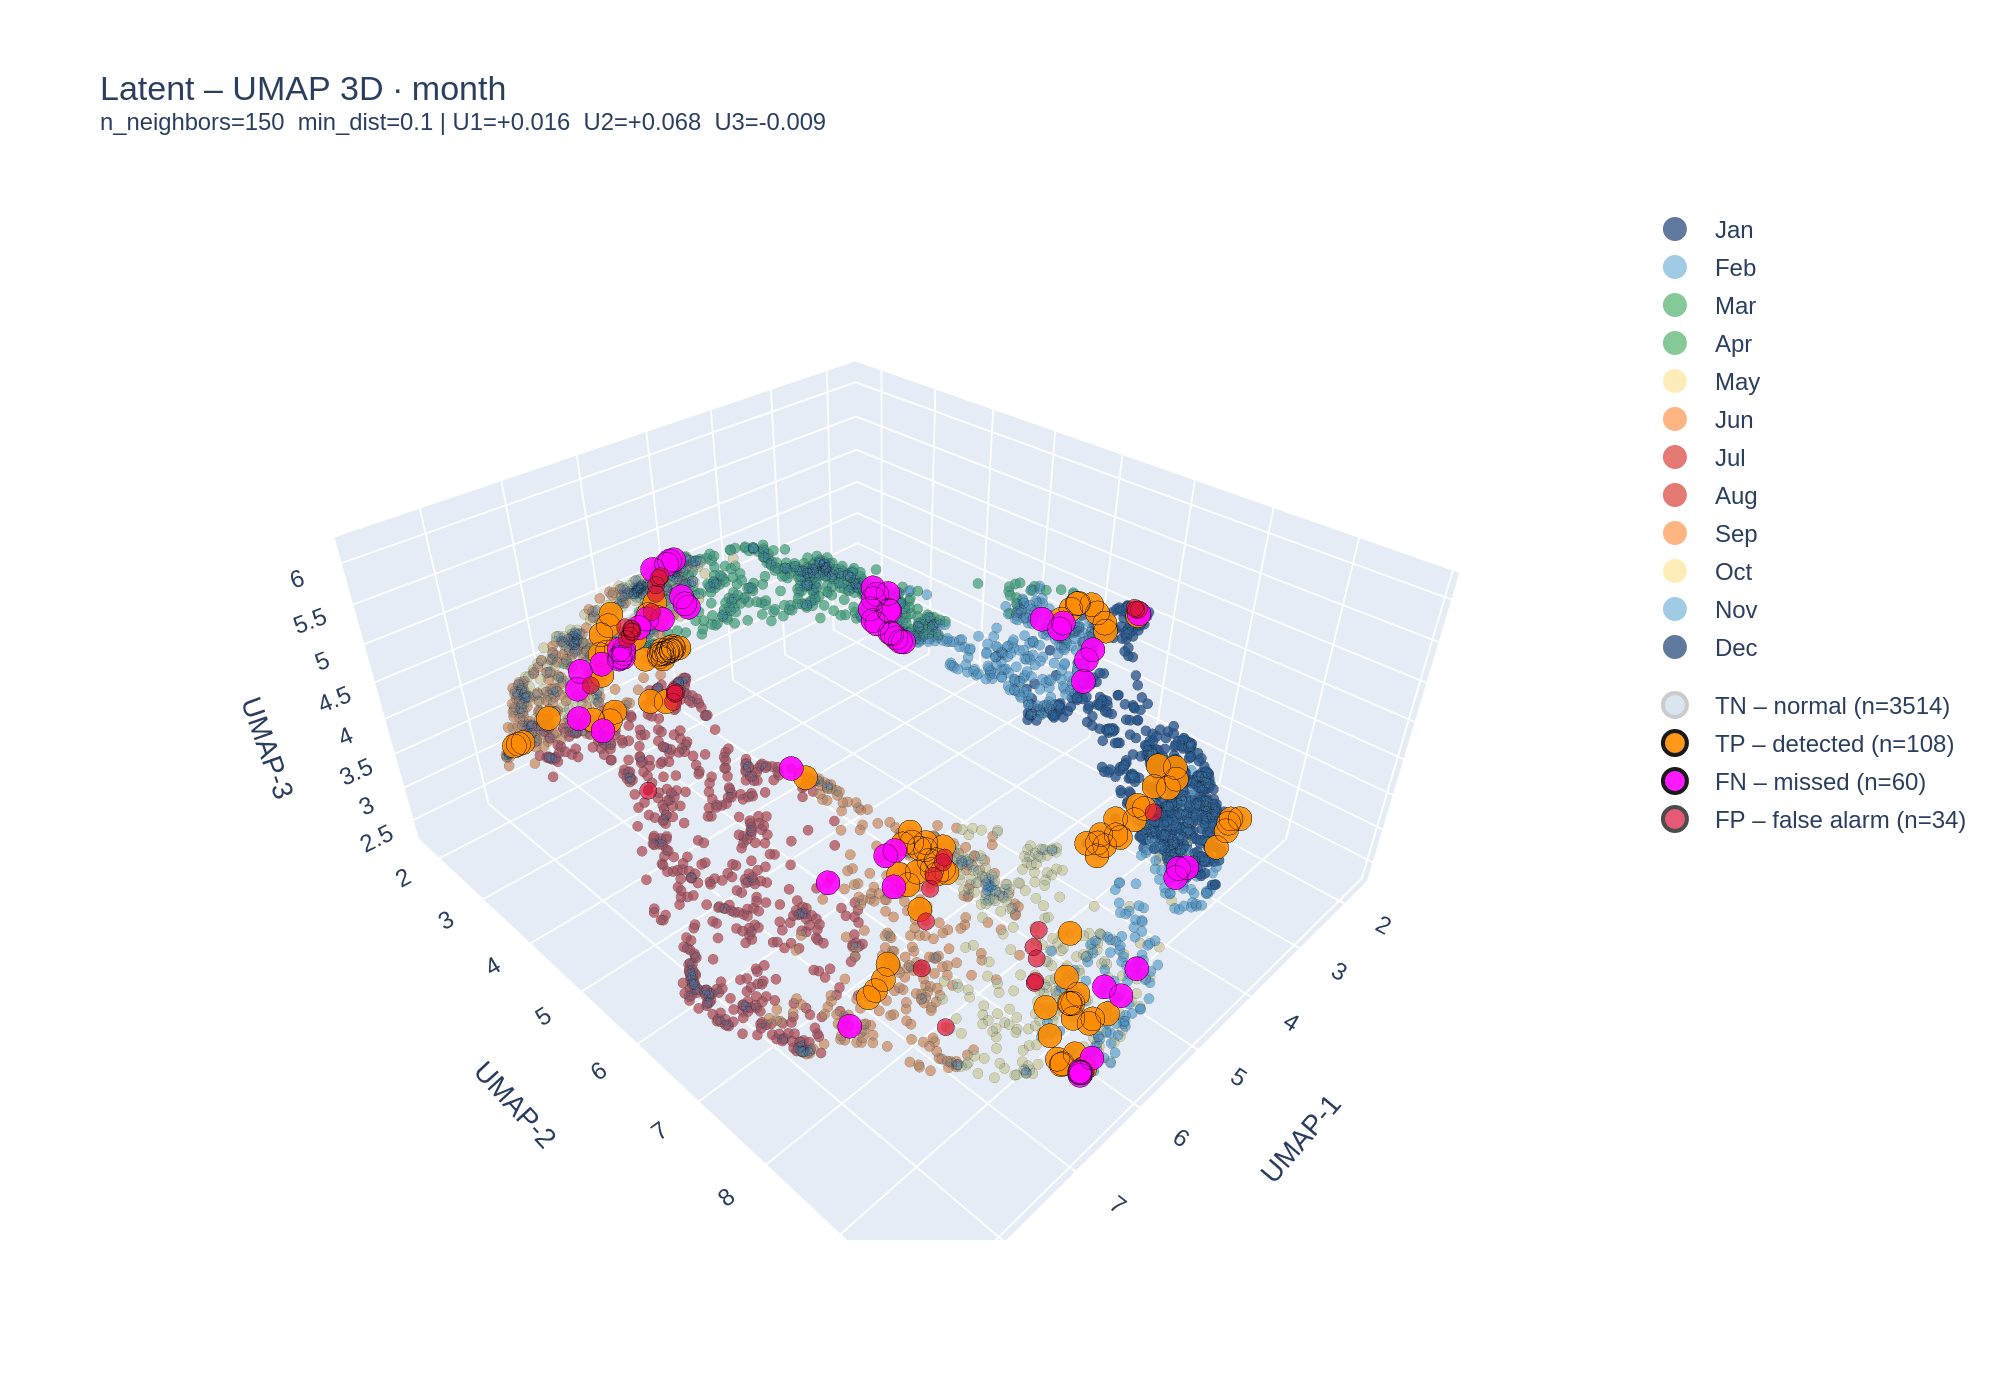

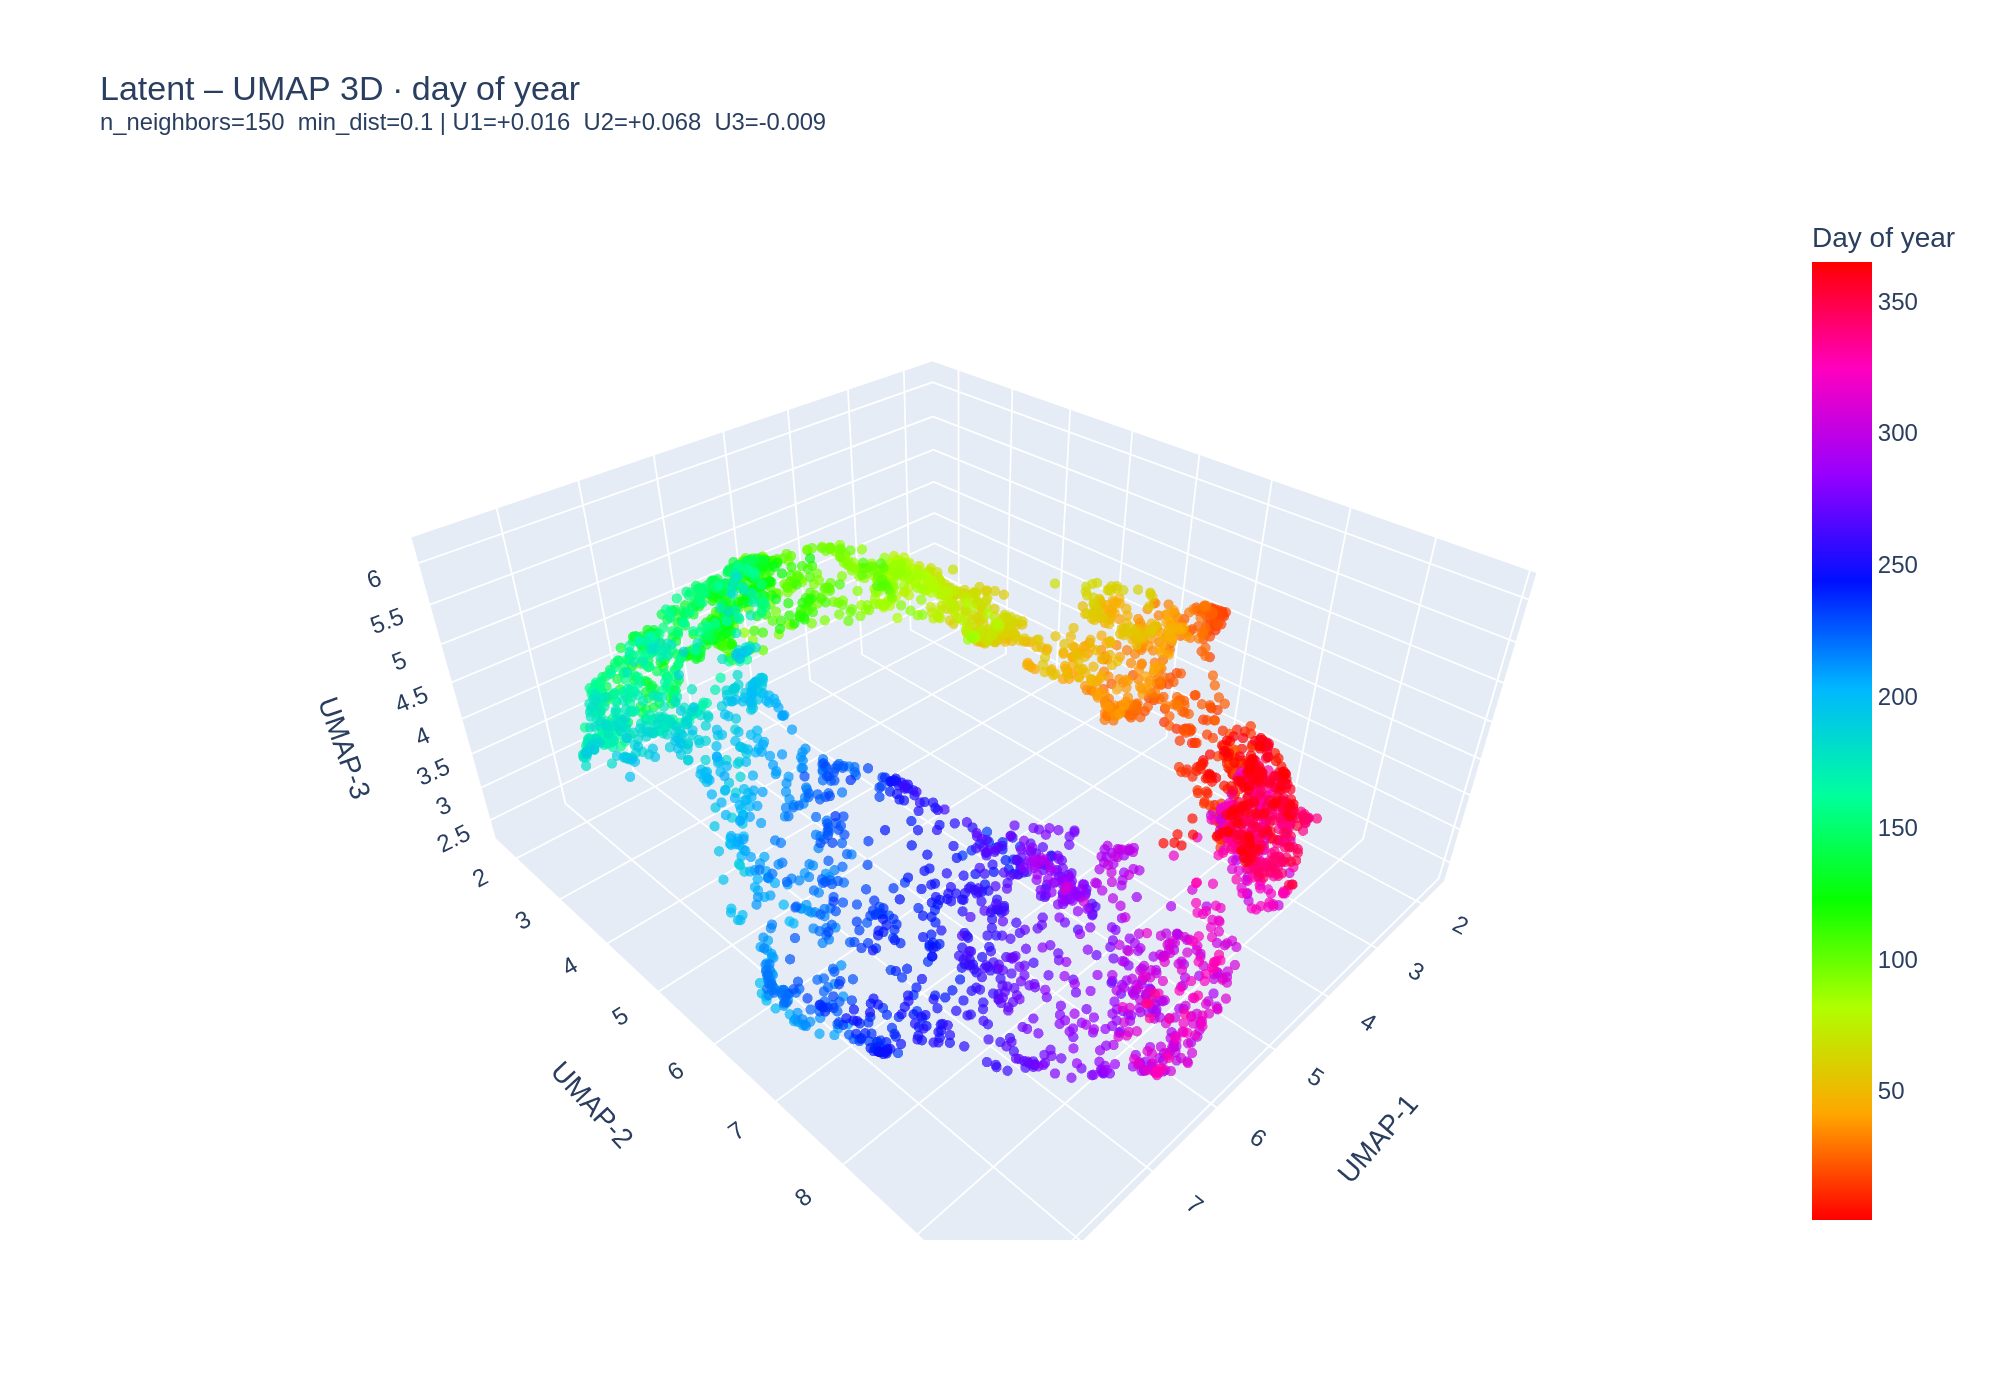

In [35]:
from IPython.display import Image, display

# latent_umap_hod (hour-of-day coloring) is intentionally not shown here:
# this demo's config uses stride=24, so every sample lands at the same hour of
# day and the plot would just be a single solid color — not informative. It's
# still generated by the command above if you want to check it yourself.
for _name in ["latent_umap_month.png","latent_umap_doy.png"]:
    display(Image(filename=f"{RUN_DIR}/{_name}"))

In [ ]:
from IPython.display import HTML, display

# Interactive version — only attempted in Colab (IN_COLAB, set when this
# notebook cloned the repo above). It depends on loading Plotly's JS from an
# external CDN, which GitHub's and VS Code's notebook previews block, so it
# would render as nothing there even though the file is saved correctly.
if IN_COLAB:
    for _name in ["latent_umap_month.html", "latent_umap_doy.html"]:
        with open(f"{RUN_DIR}/{_name}", encoding="utf-8") as _f:
            display(HTML(_f.read()))

### Download this run

Off by default — see the cell below to enable it.

In [ ]:
# Set to True and re-run this cell to download a zip of the run directory
# (RUN_DIR), covering this run.
DOWNLOAD_RUN_DIR = False

import shutil

if not DOWNLOAD_RUN_DIR:
    print(
        "Run directory not downloaded (DOWNLOAD_RUN_DIR=False). "
        "To download it, set DOWNLOAD_RUN_DIR = True above and re-run this cell."
    )
else:
    from google.colab import files

    archive_path = shutil.make_archive(RUN_DIR.rstrip("/").replace("/", "_"), "zip", RUN_DIR)
    print(f"Zipped {RUN_DIR} -> {archive_path}")
    files.download(archive_path)

Run directory not downloaded (DOWNLOAD_RUN_DIR=False). To download it, set DOWNLOAD_RUN_DIR = True above and re-run this cell.
